# Patch position experiment

Sweep fixed patch positions over the image and measure attack success. Success is `clean P(person) - patched P(person) > 0.5`. The default grid step is 16 px, including exact right/bottom borders.

In [1]:
from pathlib import Path
import sys

LAB_ROOT = Path.cwd()
if (LAB_ROOT / "classifier_patch_analysis").exists():
    REPO_ROOT = LAB_ROOT.parent
else:
    REPO_ROOT = LAB_ROOT
    LAB_ROOT = REPO_ROOT / "classifier_experiments"
sys.path.insert(0, str(LAB_ROOT))

In [2]:
from classifier_patch_analysis import ClassifierAttackConfig, ClassifierPatchExperiment, ExperimentConfig

SEED = 17
IMG_SIZE = 224
MODEL_CHECKPOINT = str(REPO_ROOT / "data" / "yolo11-cls-person.pt")
BASE_WEIGHTS = str(REPO_ROOT / "data" / "yolo11s-cls.pt")
PATCH_PATH = str(REPO_ROOT / "data" / "cls_patch.png")
DATASET_PATH = str(REPO_ROOT / "datasets" / "COCO_people_224")
DEVICE = "auto"
BATCH_SIZE = 64
SUCCESS_DROP_THRESHOLD = 0.5
TARGET_LAYER = "model.9"

attack_config = ClassifierAttackConfig(
    dataset_path=DATASET_PATH,
    patch_path=PATCH_PATH,
    checkpoint_path=MODEL_CHECKPOINT,
    base_weights_path=BASE_WEIGHTS,
    output_dir=str(LAB_ROOT / "outputs" / "classifier_patch_analysis"),
    img_size=IMG_SIZE,
    device=DEVICE,
    success_drop_threshold=SUCCESS_DROP_THRESHOLD,
    inference_batch_size=BATCH_SIZE,
    seed=SEED,
)
exp = ClassifierPatchExperiment(ExperimentConfig(attack=attack_config, target_layer=TARGET_LAYER))

In [3]:
from classifier_patch_analysis import compute_or_load_position_sweep

STEP = 16
MAX_EXAMPLES = None
FORCE = False

sweep = compute_or_load_position_sweep(
    exp,
    step=STEP,
    max_examples=MAX_EXAMPLES,
    batch_size=BATCH_SIZE,
    force=FORCE,
)
rows_df = sweep["rows_df"]
display(rows_df.sort_values("ASR", ascending=False).head(15))
display(rows_df[["ASR", "mean_drop", "mean_conf_patch"]].describe())
rows_df.to_csv(exp.output_dir / "patch_position_sweep.csv", index=False)

clean logits:   0%|          | 0/5843 [00:00<?, ?img/s]

patch positions:   0%|          | 0/169 [00:00<?, ?pos/s]

,x,y,patch_x_center,patch_y_center,n,successful,unsuccessful,ASR,mean_drop,median_drop,mean_conf_clean,mean_conf_patch
143,0,176,20.0,196.0,5843,5487,356,0.939072,0.839313,0.901583,0.929461,0.090148
19,96,16,116.0,36.0,5843,5459,384,0.934280,0.835401,0.900552,0.929461,0.094060
91,0,112,20.0,132.0,5843,5458,385,0.934109,0.841647,0.908099,0.929461,0.087814
117,0,144,20.0,164.0,5843,5453,390,0.933253,0.836230,0.901557,0.929461,0.093230
92,16,112,36.0,132.0,5843,5422,421,0.927948,0.840442,0.912379,0.929461,0.089019
144,16,176,36.0,196.0,5843,5422,421,0.927948,0.838109,0.909991,0.929461,0.091352
157,16,184,36.0,204.0,5843,5409,434,0.925723,0.834421,0.905949,0.929461,0.095040
20,112,16,132.0,36.0,5843,5405,438,0.925039,0.833994,0.904898,0.929461,0.095466
104,0,128,20.0,148.0,5843,5405,438,0.925039,0.819704,0.887435,0.929461,0.109756
118,16,144,36.0,164.0,5843,5404,439,0.924867,0.838594,0.911362,0.929461,0.090867


,ASR,mean_drop,mean_conf_patch
count,169.000000,169.000000,169.000000
mean,0.876749,0.778071,0.151389
std,0.041716,0.041580,0.041580
min,0.719322,0.644552,0.087814
25%,0.859319,0.752895,0.122944
50%,0.887215,0.785336,0.144124
75%,0.905357,0.806517,0.176566
max,0.939072,0.841647,0.284909


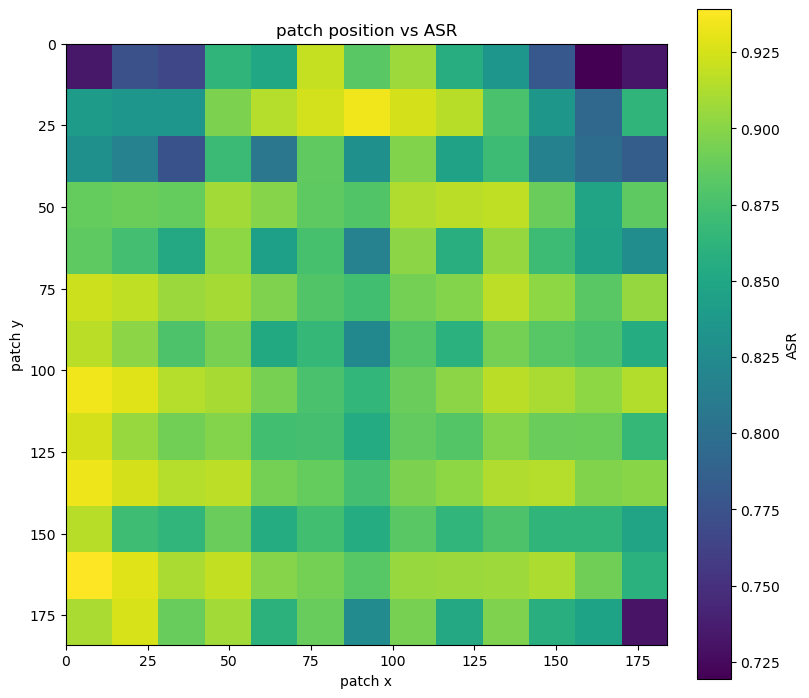

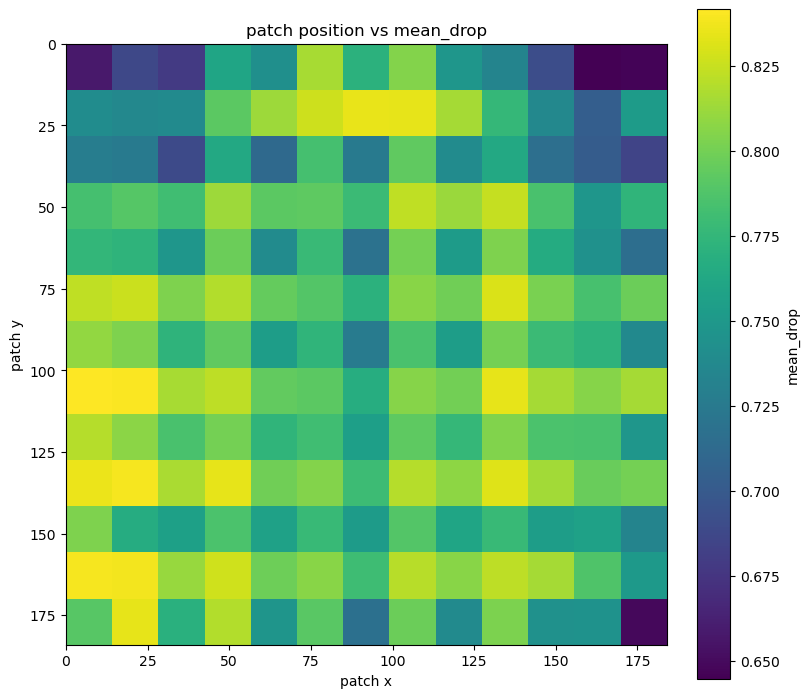

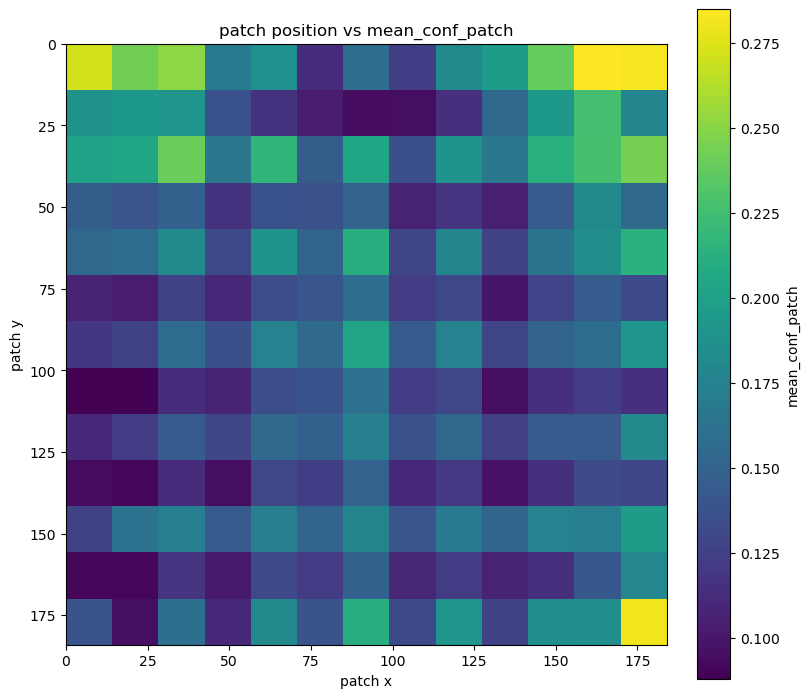

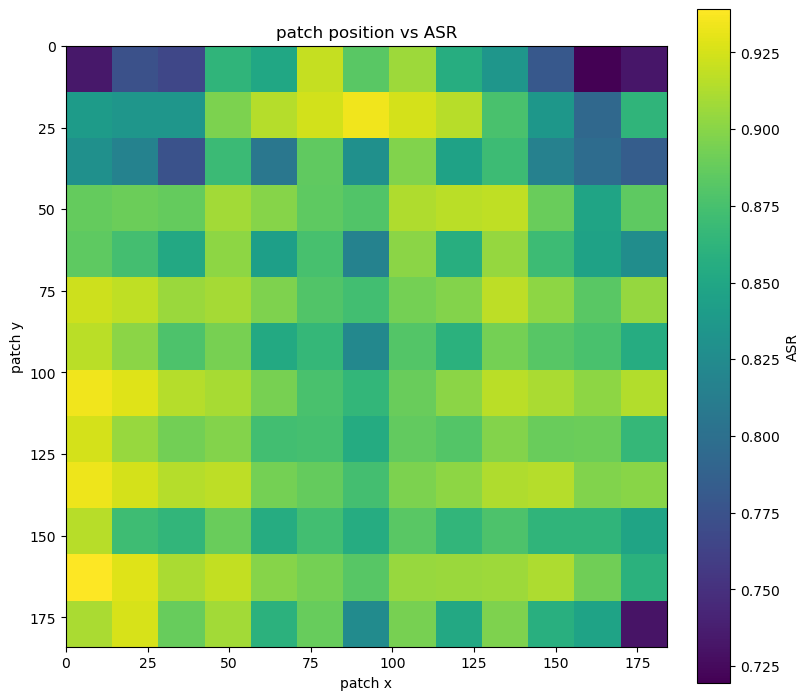

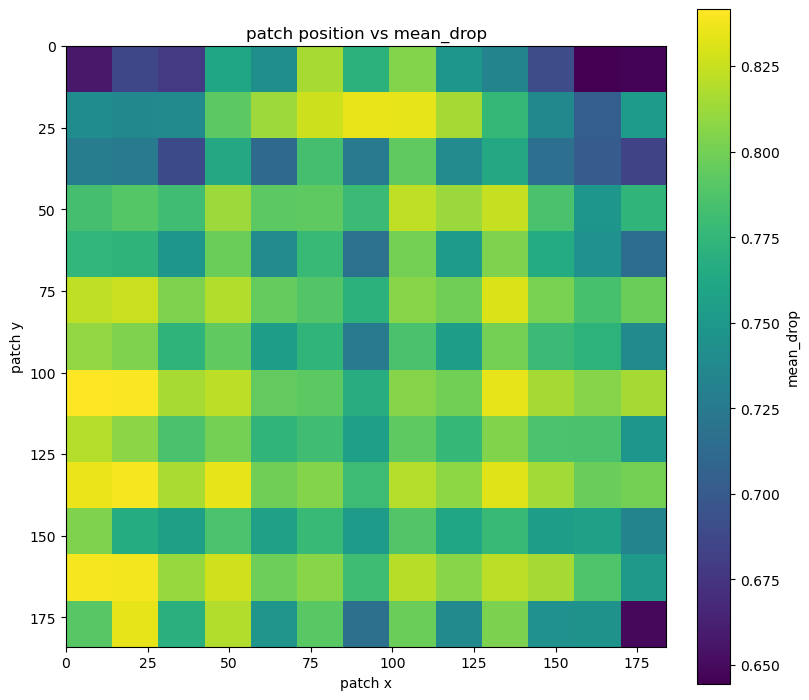

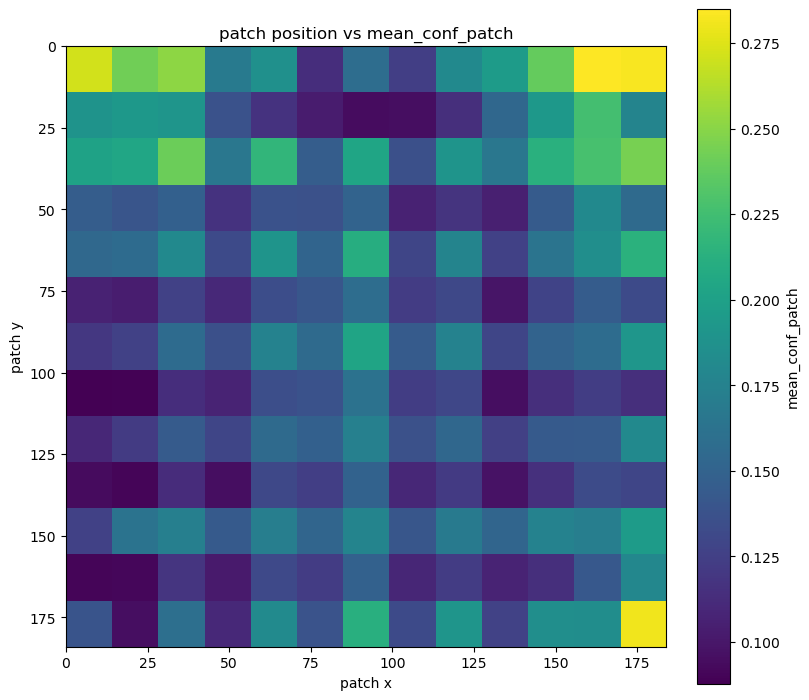

In [4]:
from classifier_patch_analysis.plots import plot_position_heatmap, savefig

for value_col in ["ASR", "mean_drop", "mean_conf_patch"]:
    fig = plot_position_heatmap(rows_df, value_col=value_col)
    savefig(fig, exp.figures_dir / f"patch_position_{value_col}.png")
    display(fig)

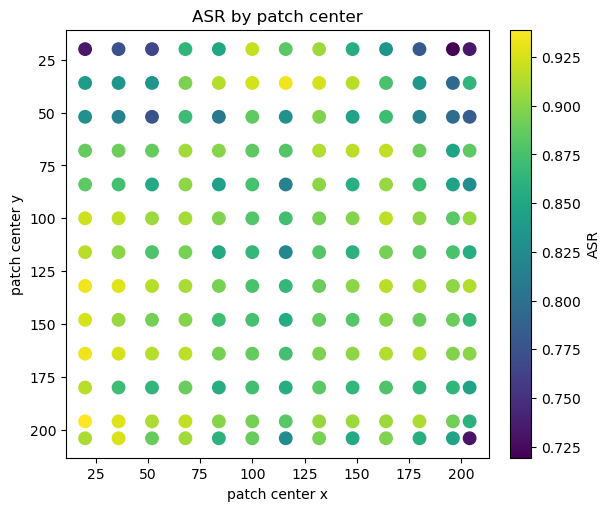

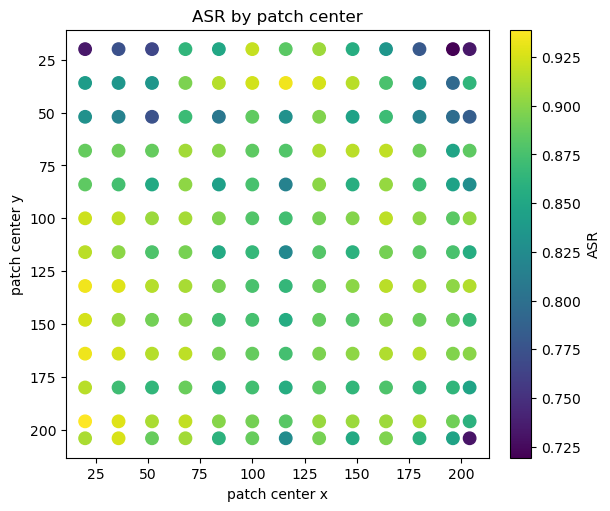

: 

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 5), constrained_layout=True)
sc = ax.scatter(rows_df["patch_x_center"], rows_df["patch_y_center"], c=rows_df["ASR"], s=80, cmap="viridis")
ax.invert_yaxis()
ax.set_xlabel("patch center x")
ax.set_ylabel("patch center y")
ax.set_title("ASR by patch center")
fig.colorbar(sc, ax=ax, label="ASR")
savefig(fig, exp.figures_dir / "patch_position_center_scatter_ASR.png")
fig